## Balanced Stroke prediction dataset 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [4]:
df = pd.read_csv("stroke_risk_dataset.csv")
df.head()

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,60.0,1
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,56.5,1


In [5]:
df.info()
df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Chest Pain                      70000 non-null  int64  
 1   Shortness of Breath             70000 non-null  int64  
 2   Irregular Heartbeat             70000 non-null  int64  
 3   Fatigue & Weakness              70000 non-null  int64  
 4   Dizziness                       70000 non-null  int64  
 5   Swelling (Edema)                70000 non-null  int64  
 6   Pain in Neck/Jaw/Shoulder/Back  70000 non-null  int64  
 7   Excessive Sweating              70000 non-null  int64  
 8   Persistent Cough                70000 non-null  int64  
 9   Nausea/Vomiting                 70000 non-null  int64  
 10  High Blood Pressure             70000 non-null  int64  
 11  Chest Discomfort (Activity)     70000 non-null  int64  
 12  Cold Hands/Feet                 

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
69995,1,0,0,0,0,0,0,1,0,1,1,1,0,0,1,18,30.0,0
69996,0,0,0,1,0,1,0,1,0,0,0,1,1,1,0,24,33.0,0
69997,1,1,0,1,1,1,0,0,0,0,1,0,0,0,0,49,45.5,0
69998,0,1,1,1,1,0,0,0,0,0,0,1,1,1,0,45,48.5,0
69999,0,1,0,0,0,0,0,1,1,1,1,1,0,1,0,74,63.0,1


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\372891114.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\372891114.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\372891114.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\372891114.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

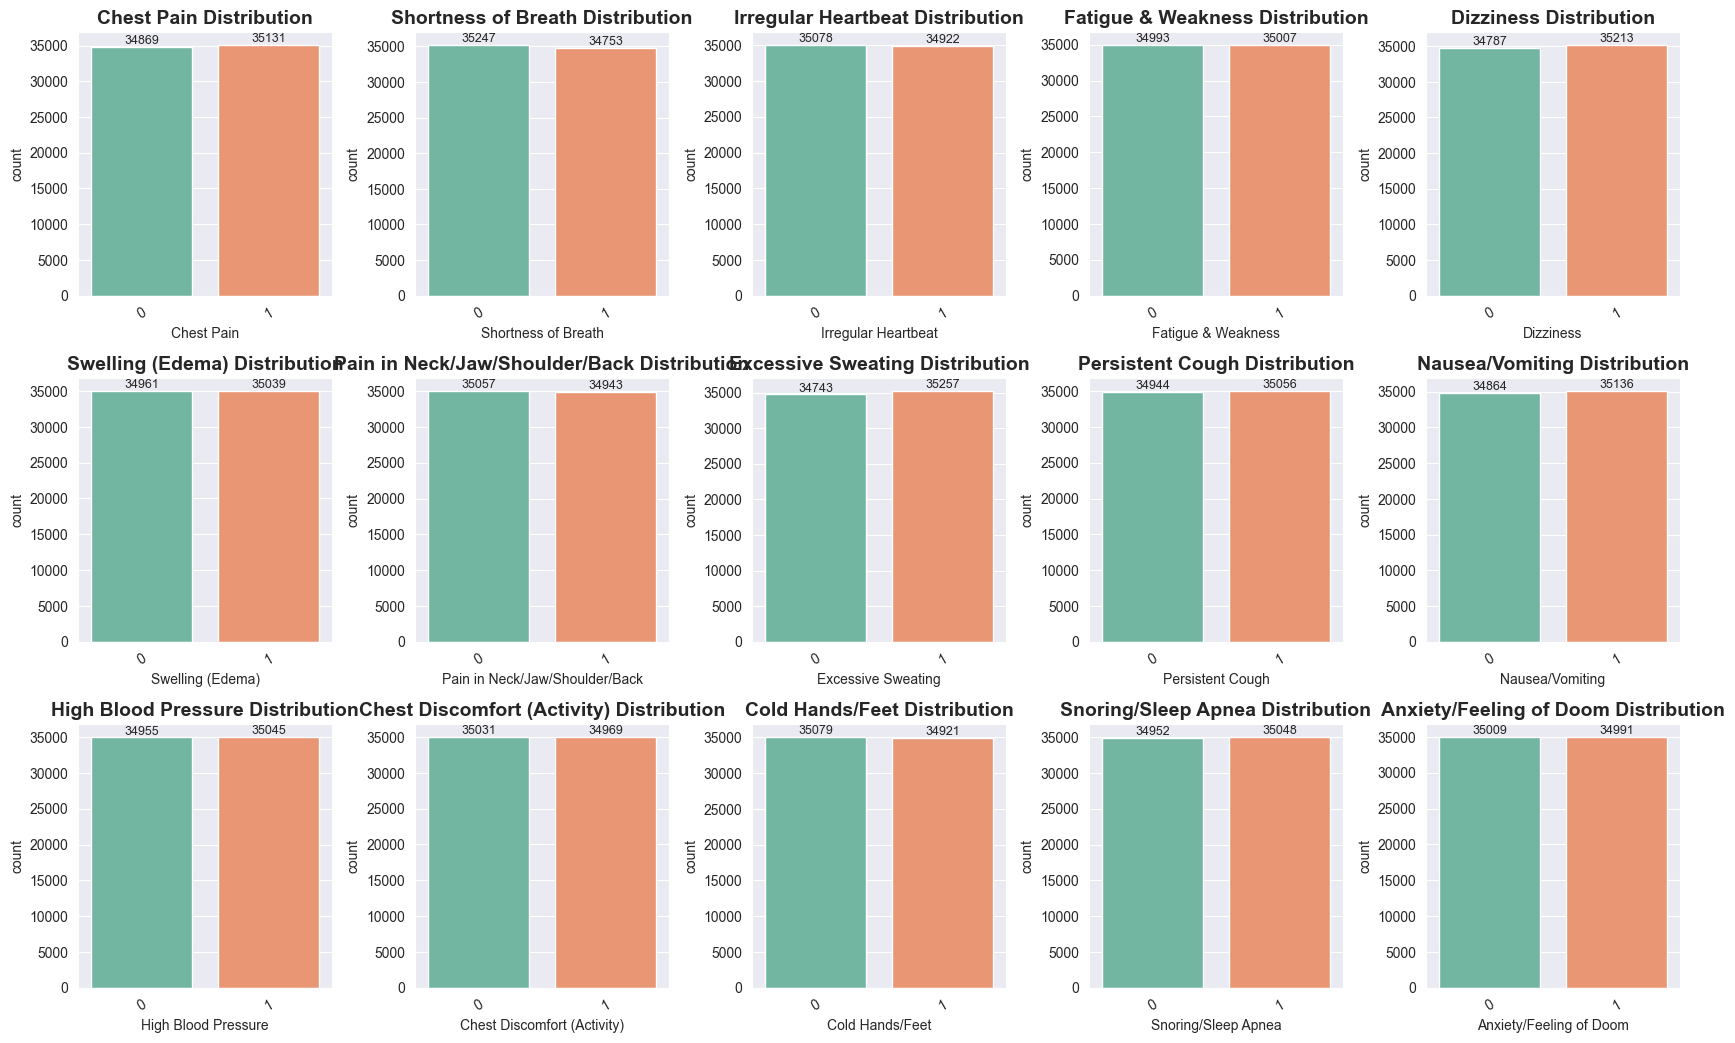

In [6]:
cols_for_count =['Chest Pain','Shortness of Breath', 'Irregular Heartbeat', 'Fatigue & Weakness',
                 'Dizziness', 'Swelling (Edema)', 'Pain in Neck/Jaw/Shoulder/Back', 'Excessive Sweating',
                 'Persistent Cough', 'Nausea/Vomiting', 'High Blood Pressure','Chest Discomfort (Activity)',
                 'Cold Hands/Feet', 'Snoring/Sleep Apnea', 'Anxiety/Feeling of Doom']

sns.set_style('darkgrid')
fig , axes = plt.subplots(5,5,figsize=( 17,17))

axes = axes.flatten()

for i , col in enumerate(cols_for_count):
    ax = sns.countplot(
        data = df,
        x=col,
        ax=axes[i],
        palette="Set2")
    
    axes[i].set_title(f"{col} Distribution", fontsize=14, weight="bold")
    axes[i].tick_params(axis='x', rotation=30)

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=9)

if len(cols_for_count) < len(axes):
    for j in range(len(cols_for_count), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\2541297887.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\2541297887.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\2541297887.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\2541297887.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` var

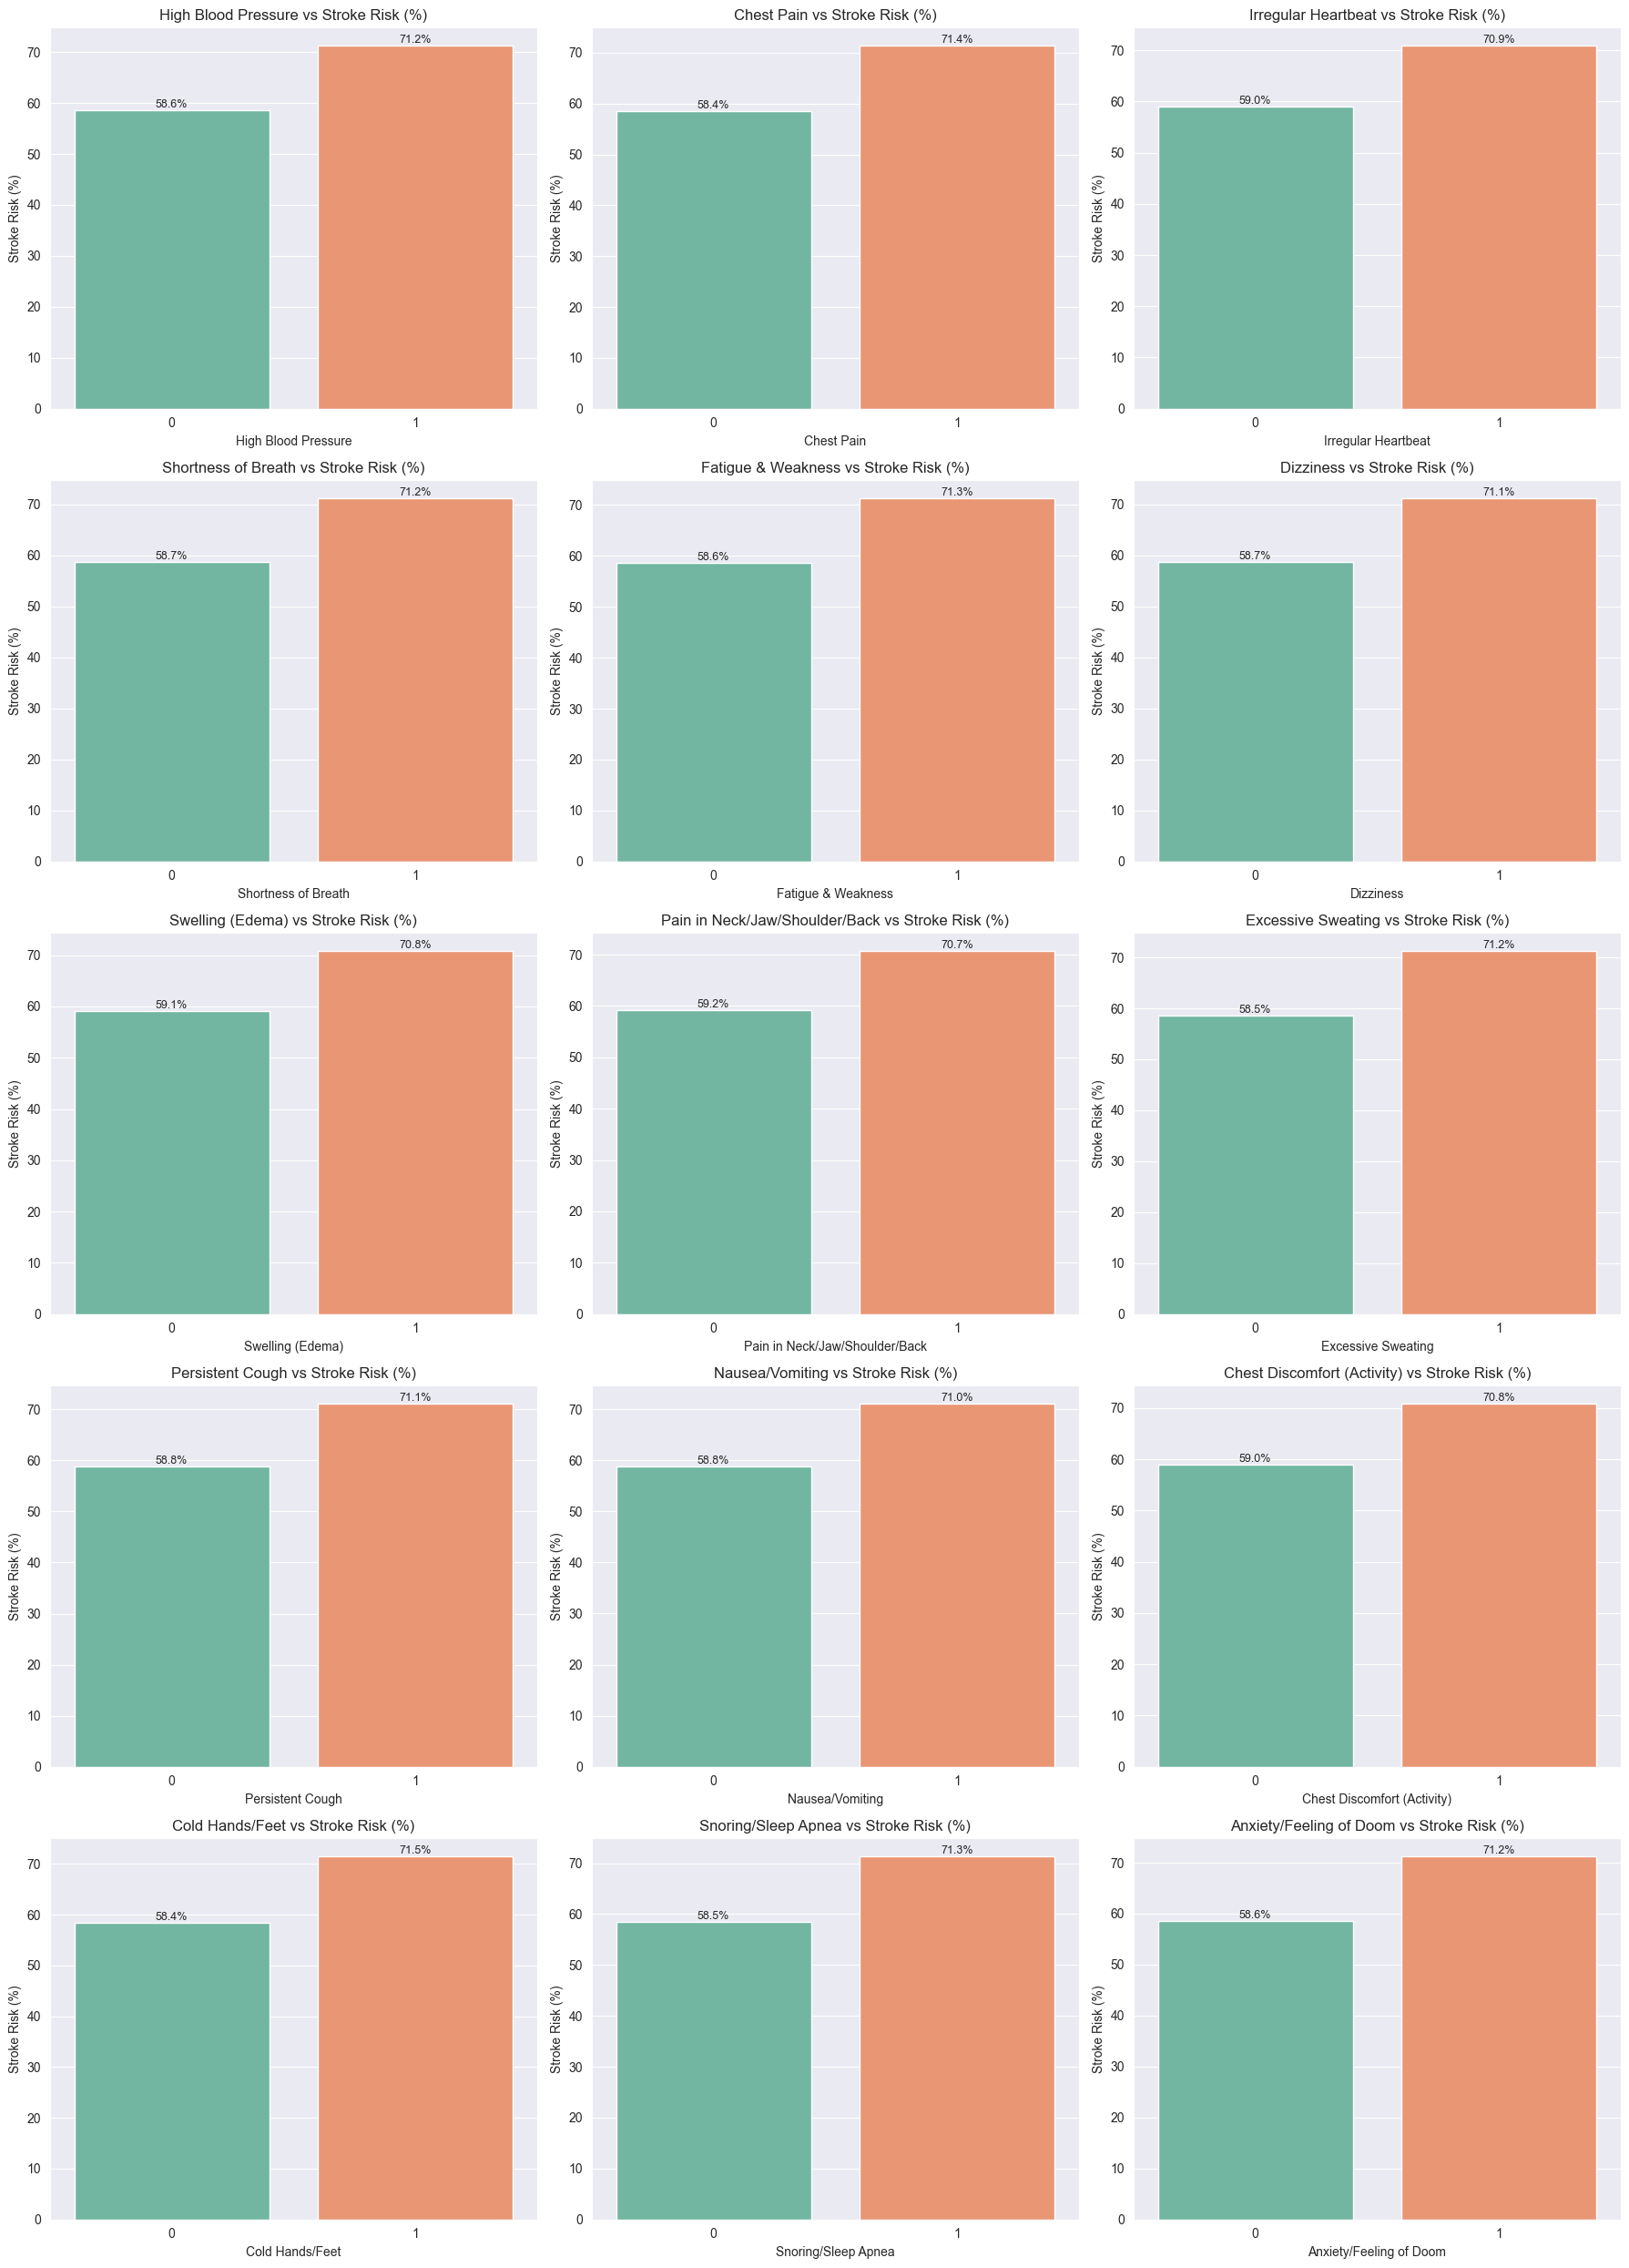

In [7]:
sns.set_style("darkgrid")

cols = [
    'High Blood Pressure',
    'Chest Pain',
    'Irregular Heartbeat',
    'Shortness of Breath',
    'Fatigue & Weakness',
    'Dizziness',
    'Swelling (Edema)',
    'Pain in Neck/Jaw/Shoulder/Back',
    'Excessive Sweating',
    'Persistent Cough', 'Nausea/Vomiting', 'Chest Discomfort (Activity)',
                 'Cold Hands/Feet', 'Snoring/Sleep Apnea', 'Anxiety/Feeling of Doom'
]

n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    
    ratio_df = (
        df.groupby(col)['At Risk (Binary)']
        .mean()
        .reset_index()
    )
    ratio_df['Stroke Risk (%)'] = ratio_df['At Risk (Binary)'] * 100
    ratio_df.drop('At Risk (Binary)', axis=1, inplace=True)

    ax = sns.barplot(
        data=ratio_df,
        x=col,
        y='Stroke Risk (%)',
        palette="Set2",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Stroke Risk (%)")

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=9
        )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
# Data Preprocessing
X = df.drop(['Stroke Risk (%)', 'At Risk (Binary)'], axis=1)
y = df['At Risk (Binary)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# For SVM, we need to scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree:")
print(f"Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, dt_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, dt_pred))
print("\n" + "="*50 + "\n")

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest:")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, rf_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, rf_pred))
print("\n" + "="*50 + "\n")

# SVM
svm_model = svm.SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

print("SVM:")
print(f"Precision: {precision_score(y_test, svm_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, svm_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, svm_pred))

Decision Tree:
Precision: 0.9111
F1 Score: 0.9107
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      4892
           1       0.91      0.91      0.91      9108

    accuracy                           0.88     14000
   macro avg       0.87      0.87      0.87     14000
weighted avg       0.88      0.88      0.88     14000



Random Forest:
Precision: 0.9538
F1 Score: 0.9603
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      4892
           1       0.95      0.97      0.96      9108

    accuracy                           0.95     14000
   macro avg       0.95      0.94      0.94     14000
weighted avg       0.95      0.95      0.95     14000



SVM:
Precision: 0.9933
F1 Score: 0.9941
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4892
           1       0.99 

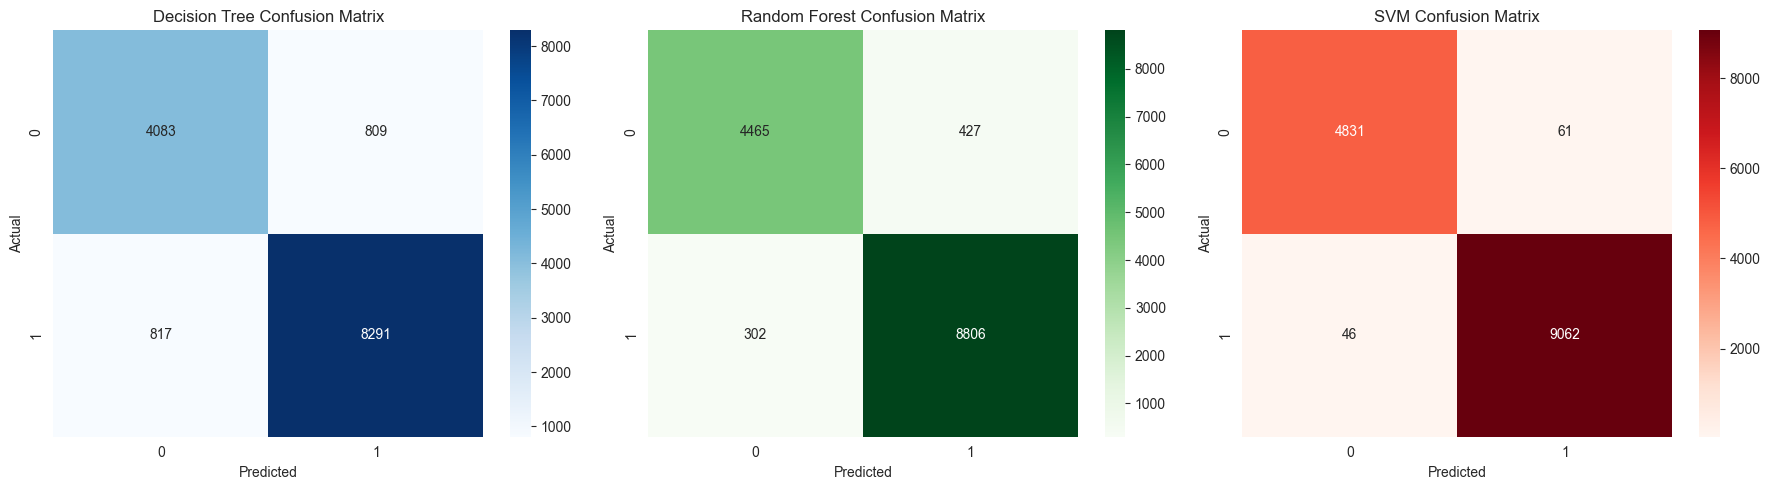

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# SVM
cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', ax=axes[2], cmap='Reds')
axes[2].set_title('SVM Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()